In [ ]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Model persistence
import joblib

# Suppress non-critical warnings for a clean, readable notebook
import warnings
warnings.filterwarnings("ignore")

# Display options: show all columns and widen the output for readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Consistent visual style for all plots in this notebook
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")


All libraries imported successfully.


In [84]:
# Load the uploaded dataset
df = pd.read_csv("cardetails.csv")

print("First five rows of the dataset:")
print(df.head())
print()
print("Last five rows of the dataset:")
print(df.tail())
print()
print("Shape of the dataset (rows, columns):", df.shape)
print()
print("Column names:", list(df.columns))
print()
print("Data types of each column:")
print(df.dtypes)


First five rows of the dataset:
                       name  year  selling_price  km_driven    fuel seller_type transmission         owner
0             Maruti 800 AC  2007          60000      70000  Petrol  Individual       Manual   First Owner
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol  Individual       Manual   First Owner
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel  Individual       Manual   First Owner
3    Datsun RediGO T Option  2017         250000      46000  Petrol  Individual       Manual   First Owner
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel  Individual       Manual  Second Owner

Last five rows of the dataset:
                                     name  year  selling_price  km_driven    fuel seller_type transmission         owner
4335  Hyundai i20 Magna 1.4 CRDi (Diesel)  2014         409999      80000  Diesel  Individual       Manual  Second Owner
4336           Hyundai i20 Magna 1.4 CRDi  2014     

In [85]:
import io

# Structural summary: column dtypes, non-null counts, memory footprint
buf = io.StringIO()
df.info(buf=buf)
print("DataFrame.info() output:")
print(buf.getvalue())

print("Statistical summary of numerical columns:")
print(df.describe())
print()

# Statistical summary of categorical (text) columns
print("Statistical summary of categorical columns:")
print(df.describe(include="all").loc[["count", "unique", "top", "freq"]][
    ["name", "fuel", "seller_type", "transmission", "owner"]
])
print()

print("Missing values per column:")
print(df.isnull().sum())
print()

print("Total duplicate rows:", df.duplicated().sum())
print()

print("Unique value counts per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")
print()

print("Unique categories in 'fuel':", df["fuel"].unique().tolist())
print("Unique categories in 'seller_type':", df["seller_type"].unique().tolist())
print("Unique categories in 'transmission':", df["transmission"].unique().tolist())
print("Unique categories in 'owner':", df["owner"].unique().tolist())
print("Year range:", df["year"].min(), "to", df["year"].max())


DataFrame.info() output:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

Statistical summary of numerical columns:
              year  selling_price      km_driven
count  4340.000000   4.340000e+03    4340.000000
mean   2013.090783   5.041273e+05   66215.777419
std       4.215344   5.785487e+05   46644.102194
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
7

In [86]:
print("Shape before cleaning:", df.shape)

# Remove exact duplicate rows: 763 identical rows add no new information
# and would bias the model towards over-represented listings.
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate rows -> new shape: {df.shape}")

print()
print("Missing values after deduplication:")
print(df.isnull().sum().sum(), "total missing cells")


Shape before cleaning: (4340, 8)
Removed 763 duplicate rows -> new shape: (3577, 8)

Missing values after deduplication:
0 total missing cells


In [87]:
# Extract 'brand' from the 'name' column (first token of the car name)
df["brand"] = df["name"].str.split().str[0]

# Fix a known multi-word brand that a simple split() breaks: "Land Rover" -> "Land"
df["brand"] = df["brand"].replace({"Land": "Land Rover"})

print("Extracted brand examples:")
print(df[["name", "brand"]].head(8))
print()
print("Number of unique brands:", df["brand"].nunique())

# Group rare brands (fewer than 5 listings) into 'Other'
brand_counts = df["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 5].index.tolist()
print()
print("Rare brands grouped into 'Other' (<5 listings):", rare_brands)
df["brand"] = df["brand"].apply(lambda b: "Other" if b in rare_brands else b)
print("Brands remaining after grouping:", df["brand"].nunique())


Extracted brand examples:
                        name    brand
0              Maruti 800 AC   Maruti
1   Maruti Wagon R LXI Minor   Maruti
2       Hyundai Verna 1.6 SX  Hyundai
3     Datsun RediGO T Option   Datsun
4      Honda Amaze VX i-DTEC    Honda
5       Maruti Alto LX BSIII   Maruti
6  Hyundai Xcent 1.2 Kappa S  Hyundai
7   Tata Indigo Grand Petrol     Tata

Number of unique brands: 29

Rare brands grouped into 'Other' (<5 listings): ['Volvo', 'Jeep', 'Ambassador', 'OpelCorsa', 'MG', 'Force', 'Daewoo', 'Isuzu', 'Kia']
Brands remaining after grouping: 21


In [88]:
from datetime import datetime

current_year = datetime.now().year
df["car_age"] = current_year - df["year"]
print(f"Created 'car_age' using current year = {current_year}")
print(df[["year", "car_age"]].head())


Created 'car_age' using current year = 2026
   year  car_age
0  2007       19
1  2007       19
2  2012       14
3  2017        9
4  2014       12


In [89]:
def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ["selling_price", "km_driven"]:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: IQR bounds = [{low:,.0f}, {high:,.0f}] -> {n_out} extreme outliers (k=3.0 IQR)")
    print()

# Cap (winsorize) extreme outliers instead of deleting the rows
sp_low, sp_high = iqr_bounds(df["selling_price"])
km_low, km_high = iqr_bounds(df["km_driven"])

df["selling_price"] = df["selling_price"].clip(lower=max(sp_low, 0), upper=sp_high)
df["km_driven"] = df["km_driven"].clip(lower=max(km_low, 0), upper=km_high)
print("Capped (winsorised) ('selling_price', 'km_driven') at the 3x-IQR bounds.")
print("Row count unchanged (capping, not deletion):", df.shape[0])


selling_price: IQR bounds = [-1,000,000, 1,800,000] -> 71 extreme outliers (k=3.0 IQR)

km_driven: IQR bounds = [-126,000, 252,000] -> 18 extreme outliers (k=3.0 IQR)

Capped (winsorised) ('selling_price', 'km_driven') at the 3x-IQR bounds.
Row count unchanged (capping, not deletion): 3577


In [90]:
# Drop 'name': its useful information (brand) has already been extracted
df = df.drop(columns=["name"])

print("Final data types after cleaning:")
print(df.dtypes)
print()
print("Final shape after cleaning:", df.shape)
print()
print("Cleaned data sample:")
print(df.head())

# Save the cleaned dataset as a checkpoint
df.to_csv("cardetails_cleaned.csv", index=False)


Final data types after cleaning:
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
brand            object
car_age           int64
dtype: object

Final shape after cleaning: (3577, 9)

Cleaned data sample:
   year  selling_price  km_driven    fuel seller_type transmission         owner    brand  car_age
0  2007          60000      70000  Petrol  Individual       Manual   First Owner   Maruti       19
1  2007         135000      50000  Petrol  Individual       Manual   First Owner   Maruti       19
2  2012         600000     100000  Diesel  Individual       Manual   First Owner  Hyundai       14
3  2017         250000      46000  Petrol  Individual       Manual   First Owner   Datsun        9
4  2014         450000     141000  Diesel  Individual       Manual  Second Owner    Honda       12


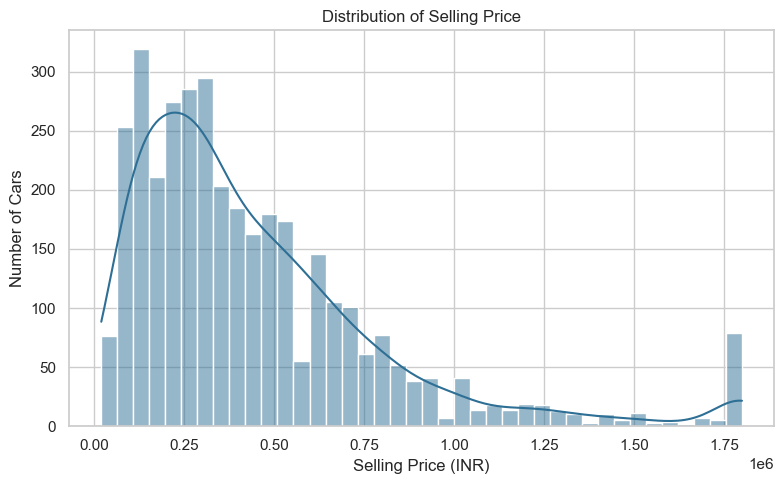

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["selling_price"], bins=40, kde=True, color="#2E6F95", ax=ax)
ax.set_title("Distribution of Selling Price")
ax.set_xlabel("Selling Price (INR)")
ax.set_ylabel("Number of Cars")
plt.tight_layout()
plt.show()


### 5.2 — Distribution of Kilometers Driven

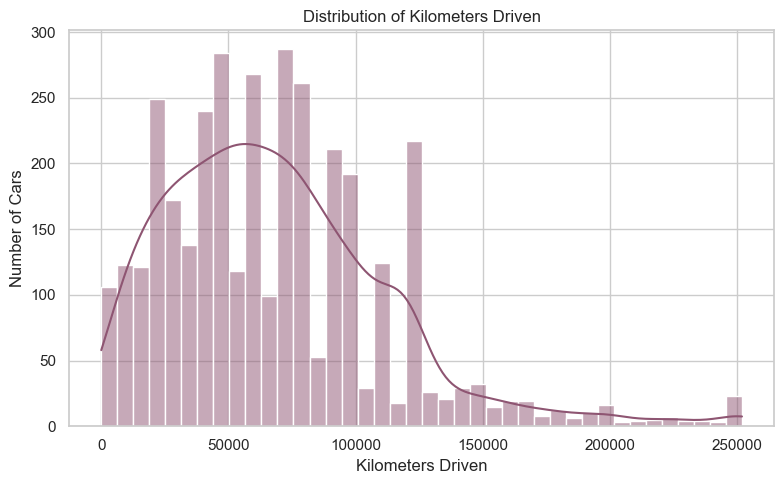

In [92]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["km_driven"], bins=40, kde=True, color="#8E5572", ax=ax)
ax.set_title("Distribution of Kilometers Driven")
ax.set_xlabel("Kilometers Driven")
ax.set_ylabel("Number of Cars")
plt.tight_layout()
plt.show()


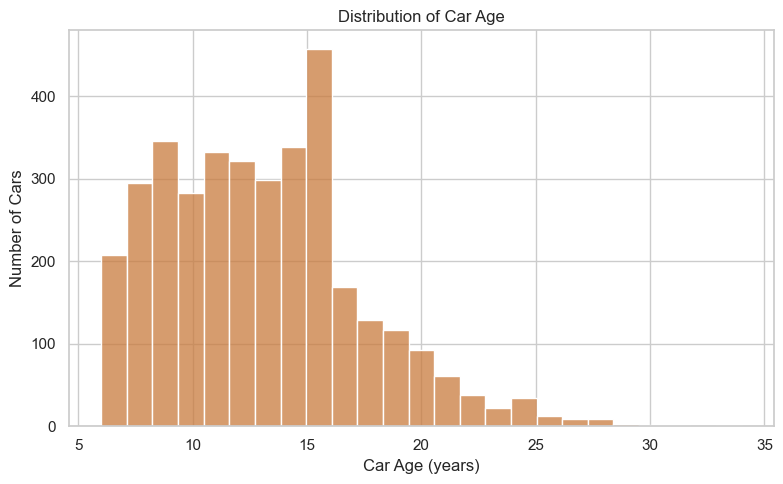

In [93]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["car_age"], bins=25, kde=False, color="#C97B3D", ax=ax)
ax.set_title("Distribution of Car Age")
ax.set_xlabel("Car Age (years)")
ax.set_ylabel("Number of Cars")
plt.tight_layout()
plt.show()


### 5.4 — Count of Cars by Fuel Type

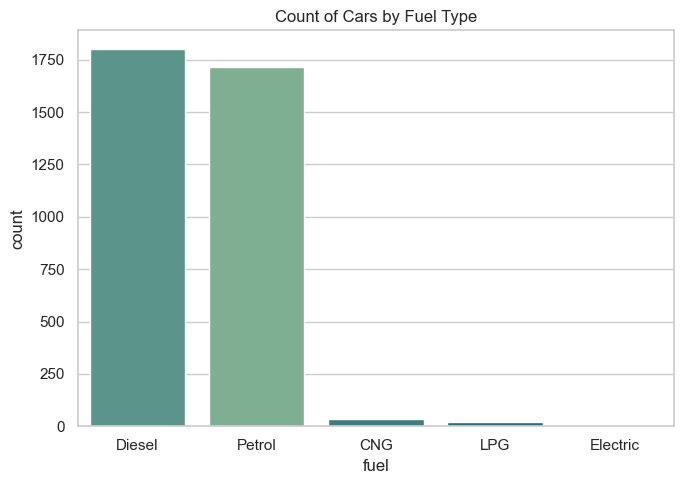

In [94]:
fig, ax = plt.subplots(figsize=(7, 5))
order = df["fuel"].value_counts().index
sns.countplot(data=df, x="fuel", order=order, hue="fuel", palette="crest", legend=False, ax=ax)
ax.set_title("Count of Cars by Fuel Type")
plt.tight_layout()
plt.show()


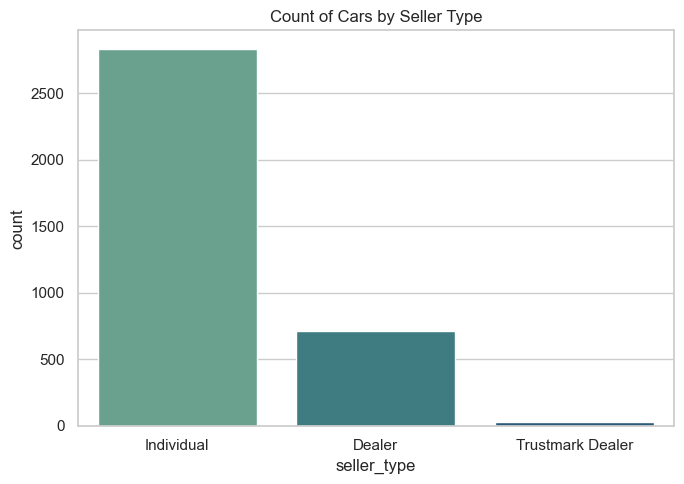

In [95]:
fig, ax = plt.subplots(figsize=(7, 5))
order = df["seller_type"].value_counts().index
sns.countplot(data=df, x="seller_type", order=order, hue="seller_type", palette="crest", legend=False, ax=ax)
ax.set_title("Count of Cars by Seller Type")
plt.tight_layout()
plt.show()


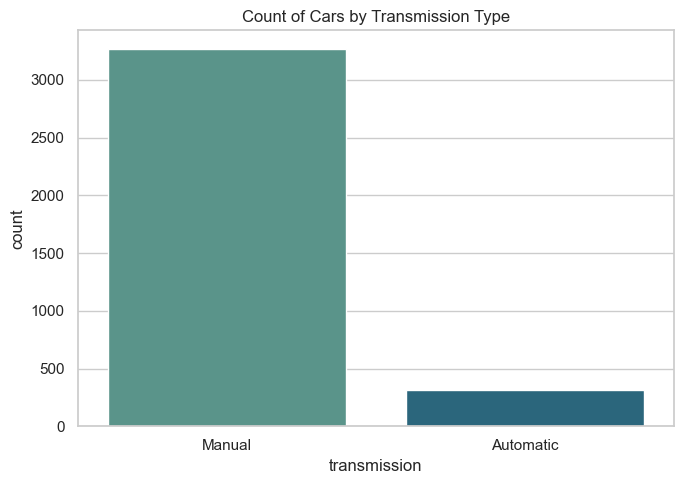

In [96]:
fig, ax = plt.subplots(figsize=(7, 5))
order = df["transmission"].value_counts().index
sns.countplot(data=df, x="transmission", order=order, hue="transmission", palette="crest", legend=False, ax=ax)
ax.set_title("Count of Cars by Transmission Type")
plt.tight_layout()
plt.show()


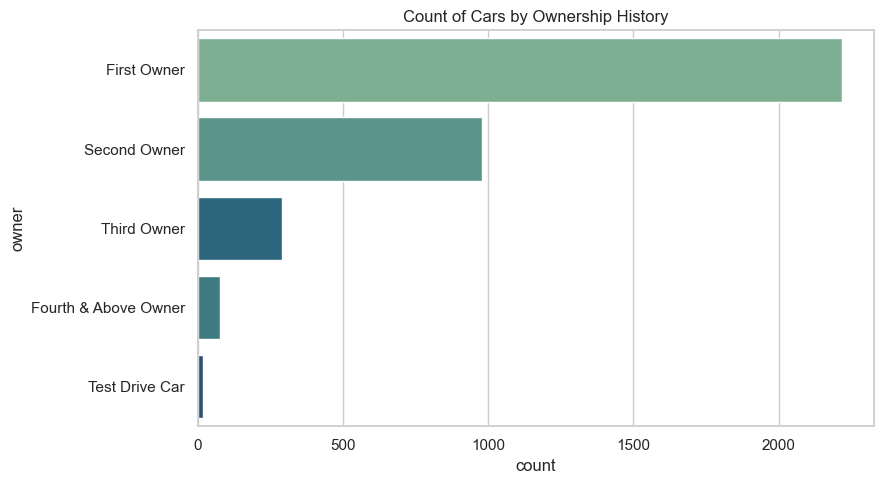

In [97]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df["owner"].value_counts().index
sns.countplot(data=df, y="owner", order=order, hue="owner", palette="crest", legend=False, ax=ax)
ax.set_title("Count of Cars by Ownership History")
plt.tight_layout()
plt.show()


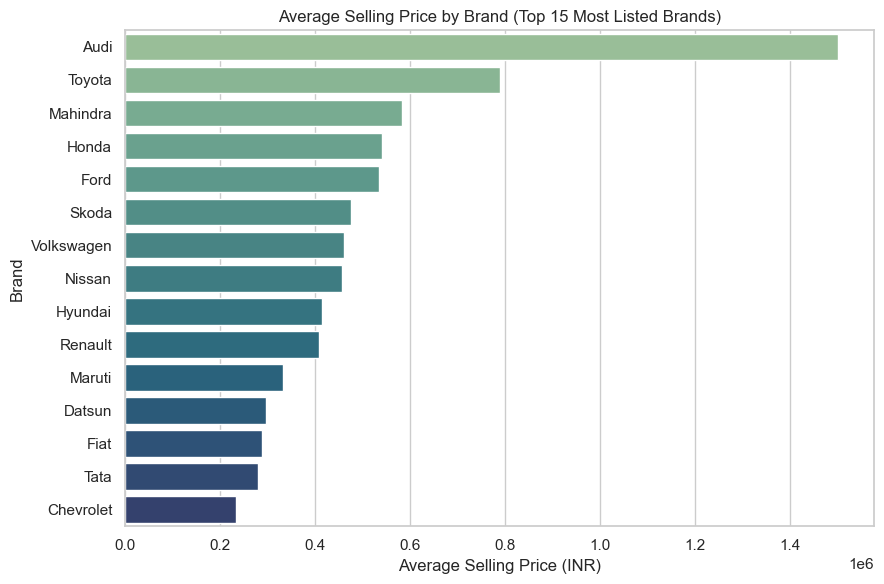

Average selling price by brand (top 15 by listing count):
brand
Audi          1.502226e+06
Toyota        7.898294e+05
Mahindra      5.818841e+05
Honda         5.399444e+05
Ford          5.347636e+05
Skoda         4.755510e+05
Volkswagen    4.616666e+05
Nissan        4.570384e+05
Hyundai       4.133406e+05
Renault       4.084000e+05
Maruti        3.320312e+05
Datsun        2.965517e+05
Fiat          2.870937e+05
Tata          2.786724e+05
Chevrolet     2.327132e+05
Name: selling_price, dtype: float64


In [98]:
top_brands = df["brand"].value_counts().head(15).index
brand_avg_price = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")["selling_price"].mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=brand_avg_price.values, y=brand_avg_price.index,
            hue=brand_avg_price.index, palette="crest", legend=False, ax=ax)
ax.set_title("Average Selling Price by Brand (Top 15 Most Listed Brands)")
ax.set_xlabel("Average Selling Price (INR)")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()

print("Average selling price by brand (top 15 by listing count):")
print(brand_avg_price)


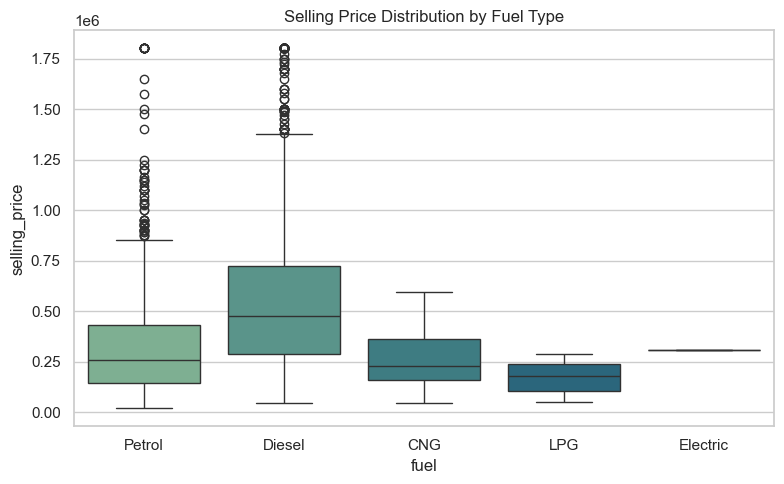

Median selling price by fuel type:
fuel
Diesel      475000.0
Electric    310000.0
Petrol      260000.0
CNG         229999.0
LPG         180000.0
Name: selling_price, dtype: float64


In [99]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="fuel", y="selling_price", hue="fuel", palette="crest", legend=False, ax=ax)
ax.set_title("Selling Price Distribution by Fuel Type")
plt.tight_layout()
plt.show()

print("Median selling price by fuel type:")
print(df.groupby("fuel")["selling_price"].median().sort_values(ascending=False))


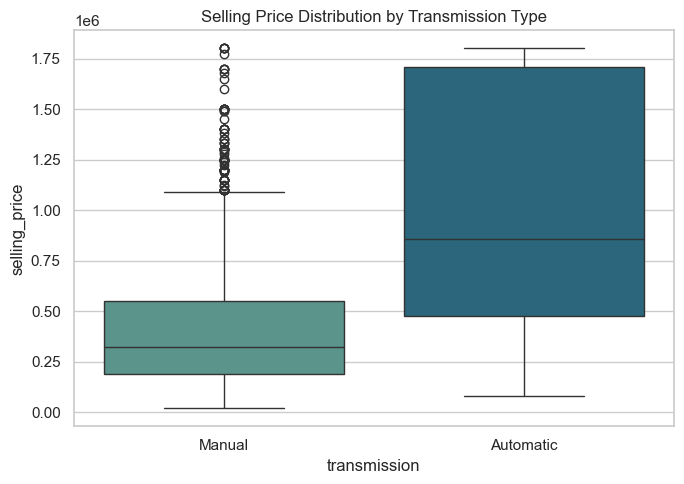

Median selling price by transmission:
transmission
Automatic    855000.0
Manual       325000.0
Name: selling_price, dtype: float64


In [100]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="transmission", y="selling_price", hue="transmission", palette="crest", legend=False, ax=ax)
ax.set_title("Selling Price Distribution by Transmission Type")
plt.tight_layout()
plt.show()

print("Median selling price by transmission:")
print(df.groupby("transmission")["selling_price"].median().sort_values(ascending=False))


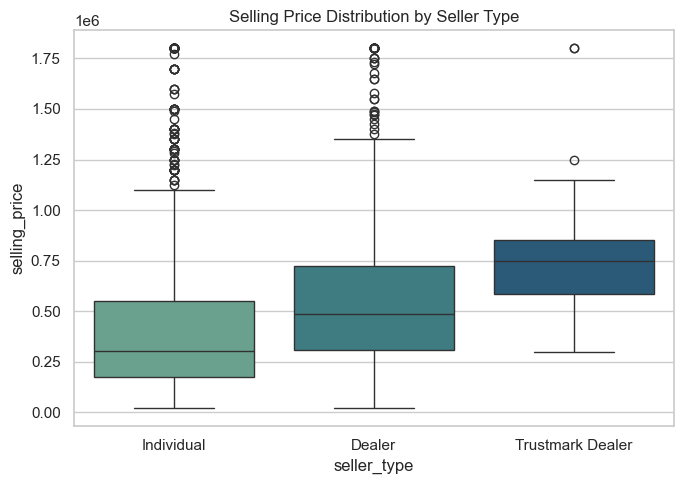

Median selling price by seller type:
seller_type
Trustmark Dealer    750000.0
Dealer              484999.0
Individual          303500.0
Name: selling_price, dtype: float64


In [101]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="seller_type", y="selling_price", hue="seller_type", palette="crest", legend=False, ax=ax)
ax.set_title("Selling Price Distribution by Seller Type")
plt.tight_layout()
plt.show()

print("Median selling price by seller type:")
print(df.groupby("seller_type")["selling_price"].median().sort_values(ascending=False))


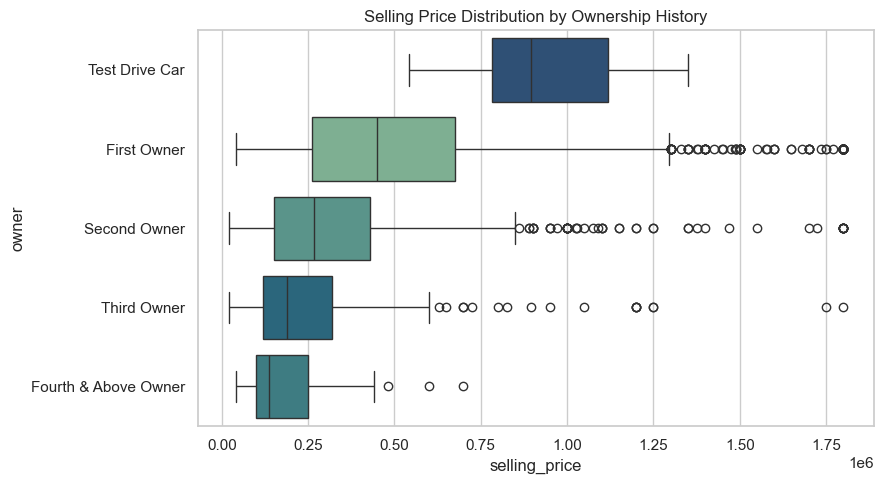

Median selling price by ownership history:
owner
Test Drive Car          894999.0
First Owner             450000.0
Second Owner            267000.0
Third Owner             190000.0
Fourth & Above Owner    138000.0
Name: selling_price, dtype: float64


In [102]:
fig, ax = plt.subplots(figsize=(9, 5))
owner_order = df.groupby("owner")["selling_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="selling_price", y="owner", order=owner_order,
            hue="owner", palette="crest", legend=False, ax=ax)
ax.set_title("Selling Price Distribution by Ownership History")
plt.tight_layout()
plt.show()

print("Median selling price by ownership history:")
print(df.groupby("owner")["selling_price"].median().sort_values(ascending=False))


### 5.13 — Car Age vs Price

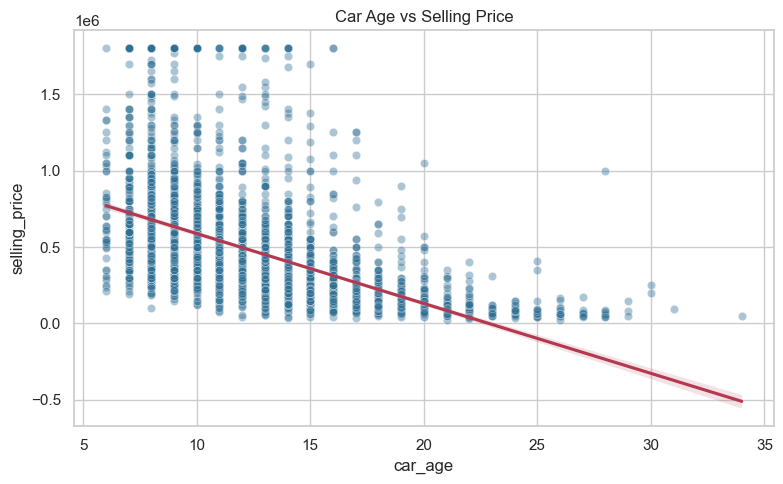

Correlation (car_age, selling_price): -0.54


In [103]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.4, color="#2E6F95", ax=ax)
sns.regplot(data=df, x="car_age", y="selling_price", scatter=False, color="#B33951", ax=ax)
ax.set_title("Car Age vs Selling Price")
plt.tight_layout()
plt.show()

print("Correlation (car_age, selling_price):", round(df["car_age"].corr(df["selling_price"]), 3))


### 5.14 — Mileage (km driven) vs Price

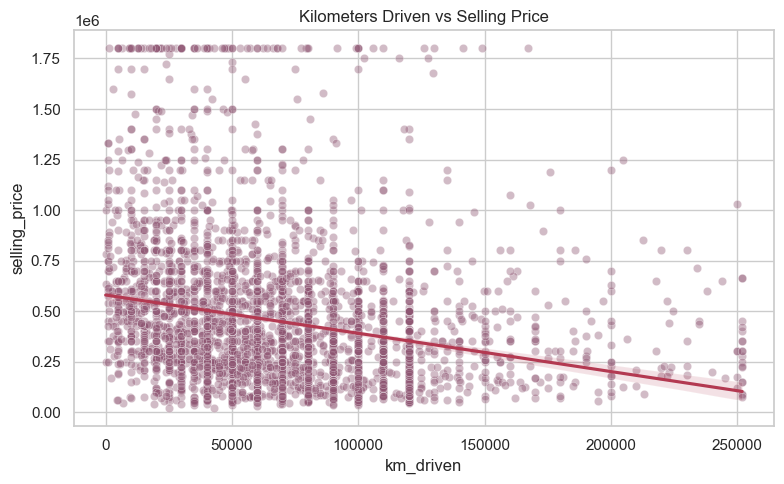

Correlation (km_driven, selling_price): -0.233


In [104]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="km_driven", y="selling_price", alpha=0.4, color="#8E5572", ax=ax)
sns.regplot(data=df, x="km_driven", y="selling_price", scatter=False, color="#B33951", ax=ax)
ax.set_title("Kilometers Driven vs Selling Price")
plt.tight_layout()
plt.show()

print("Correlation (km_driven, selling_price):", round(df["km_driven"].corr(df["selling_price"]), 3))


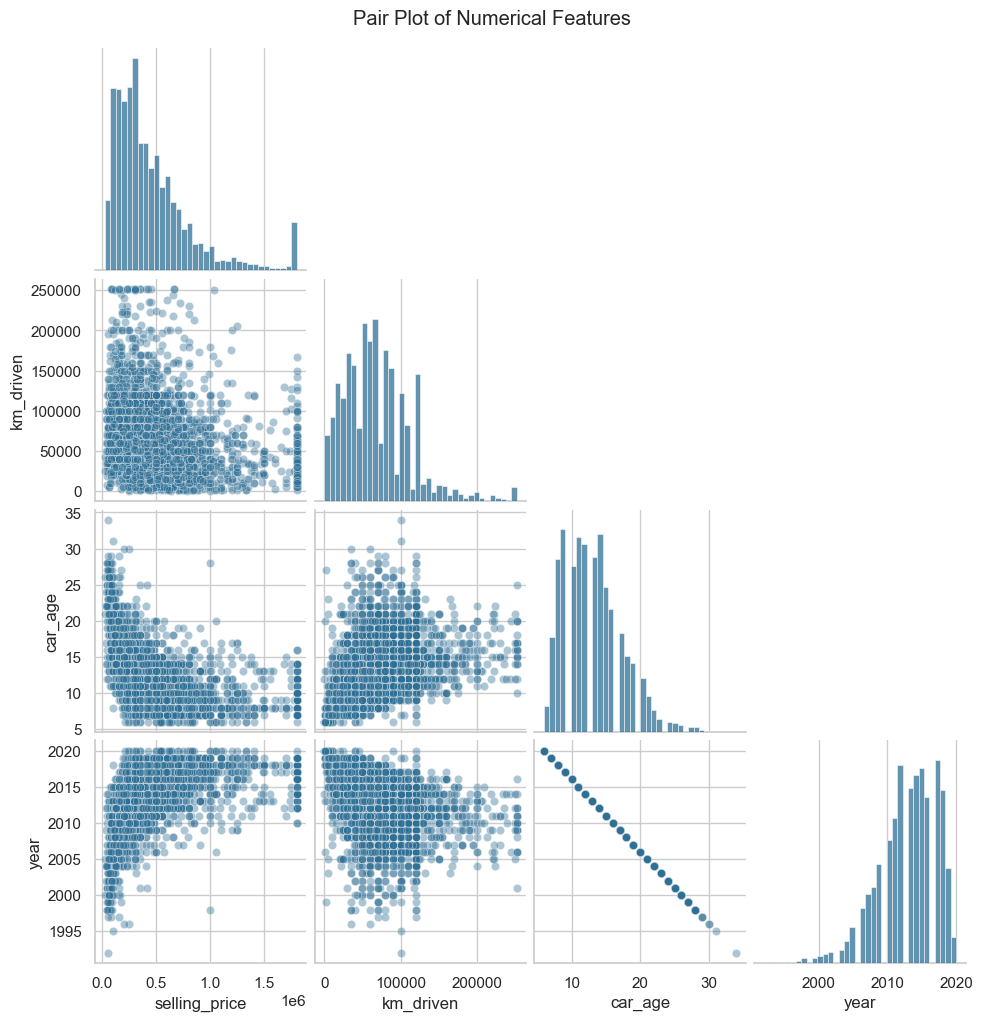

In [105]:
pair_df = df[["selling_price", "km_driven", "car_age", "year"]]
g = sns.pairplot(pair_df, corner=True, plot_kws={"alpha": 0.4, "color": "#2E6F95"},
                  diag_kws={"color": "#2E6F95"})
g.fig.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()


Correlation matrix (numeric features):
                year  selling_price  km_driven  car_age
year           1.000          0.540     -0.442   -1.000
selling_price  0.540          1.000     -0.233   -0.540
km_driven     -0.442         -0.233      1.000    0.442
car_age       -1.000         -0.540      0.442    1.000


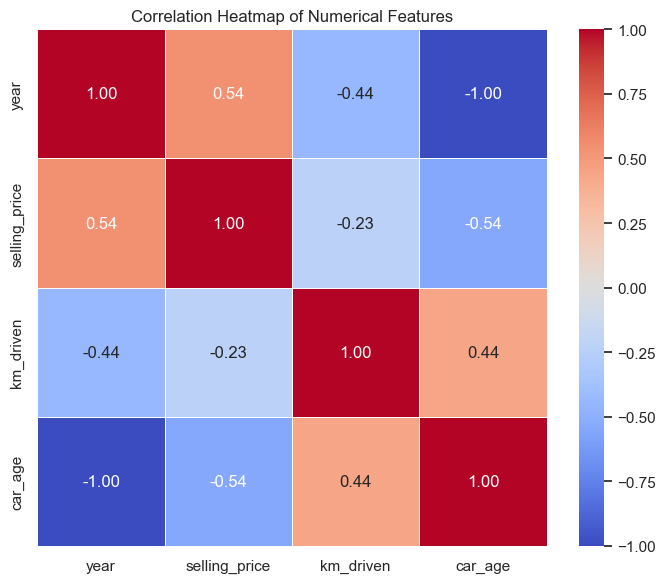


Features ranked by correlation with selling_price:
year         0.540476
km_driven   -0.232870
car_age     -0.540476
Name: selling_price, dtype: float64


In [106]:
# Correlation analysis on numeric columns only.
# Note: 'year' and 'car_age' are perfectly (negatively) collinear by
# construction (car_age = current_year - year) -- both are shown here for
# completeness, but only one will be used for modelling to avoid redundancy.
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

print("Correlation matrix (numeric features):")
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

print()
print("Features ranked by correlation with selling_price:")
price_corr = corr_matrix["selling_price"].drop("selling_price").sort_values(ascending=False)
print(price_corr)


In [107]:
# Drop 'year': perfectly collinear with 'car_age'
df = df.drop(columns=["year"])

# Compare skewness before and after a log1p transform
print("Skewness of 'selling_price' (original):", round(df["selling_price"].skew(), 3))
df["selling_price_log"] = np.log1p(df["selling_price"])
print("Skewness of 'selling_price' (log1p transformed):", round(df["selling_price_log"].skew(), 3))
print("-> The log transform brings the target distribution much closer to symmetric/normal,")
print("   which is a core assumption of linear regression, so it will be used as the modelling target.")


Skewness of 'selling_price' (original): 1.783
Skewness of 'selling_price' (log1p transformed): -0.22
-> The log transform brings the target distribution much closer to symmetric/normal,
   which is a core assumption of linear regression, so it will be used as the modelling target.


In [108]:
categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after one-hot encoding:", df_encoded.shape)
print()
print("Sample of engineered columns:")
print([c for c in df_encoded.columns
       if c not in ["selling_price", "selling_price_log", "km_driven", "car_age"]][:10], "...")


Shape after one-hot encoding: (3577, 35)

Sample of engineered columns:
['fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car'] ...


In [109]:
numeric_features = ["km_driven", "car_age"]
scaler = StandardScaler()
df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

print("Numeric features after standard scaling (mean ~0, std ~1):")
print(df_encoded[numeric_features].describe().loc[["mean", "std"]].round(3))

# Final feature set: drop the raw (untransformed) selling_price, keep the log target
df_encoded = df_encoded.drop(columns=["selling_price"])

print()
print("Final engineered dataset shape:", df_encoded.shape)
print("Final columns:", list(df_encoded.columns))

# Save engineered dataset and the fitted scaler as checkpoints
df_encoded.to_csv("cardetails_engineered.csv", index=False)
joblib.dump(scaler, "model/scaler.joblib")
print()
print("Scaler saved for future reuse on new data.")


Numeric features after standard scaling (mean ~0, std ~1):
      km_driven  car_age
mean        0.0      0.0
std         1.0      1.0

Final engineered dataset shape: (3577, 34)
Final columns: ['km_driven', 'car_age', 'selling_price_log', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner', 'brand_BMW', 'brand_Chevrolet', 'brand_Datsun', 'brand_Fiat', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Jaguar', 'brand_Land Rover', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Mitsubishi', 'brand_Nissan', 'brand_Other', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']


FileNotFoundError: [Errno 2] No such file or directory: 'model/scaler.joblib'

In [ ]:
# Separate features (X) from the target (y) -- the log-transformed selling price
X = df_encoded.drop(columns=["selling_price_log"])
y = df_encoded["selling_price_log"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# 80/20 train-test split with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print()
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Train a Linear Regression model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

print()
print("Model trained successfully.")
print("Number of coefficients learned:", len(model.coef_))
print("Intercept:", round(model.intercept_, 4))


Feature matrix shape: (3577, 33)
Target vector shape: (3577,)

Training set shape: (2861, 33)
Testing set shape: (716, 33)

Model trained successfully.
Number of coefficients learned: 33
Intercept: 13.7121


In [ ]:
# Predictions on both sets (log scale)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluation metrics on the (log-scale) test set
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

print("=== Model performance on the TEST set (log-price scale) ===")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

r2_train = r2_score(y_train, y_train_pred)
print()
print(f"For comparison, R2 Score on the TRAINING set: {r2_train:.4f}")
print("(A small gap between train and test R2 indicates the model generalizes well, without severe overfitting.)")

# Convert back to actual Rupee terms, since stakeholders think in prices, not log-prices
actual_test = np.expm1(y_test)
actual_pred = np.expm1(y_test_pred)
mae_rupees = mean_absolute_error(actual_test, actual_pred)
rmse_rupees = np.sqrt(mean_squared_error(actual_test, actual_pred))

print()
print("=== Same metrics converted back to actual Rupee (INR) scale ===")
print(f"MAE  (INR) : {mae_rupees:,.0f}")
print(f"RMSE (INR) : {rmse_rupees:,.0f}")


=== Model performance on the TEST set (log-price scale) ===
R2 Score : 0.7714
MAE      : 0.3007
MSE      : 0.1463
RMSE     : 0.3825

For comparison, R2 Score on the TRAINING set: 0.7737
(A small gap between train and test R2 indicates the model generalizes well, without severe overfitting.)

=== Same metrics converted back to actual Rupee (INR) scale ===
MAE  (INR) : 126,400
RMSE (INR) : 193,064


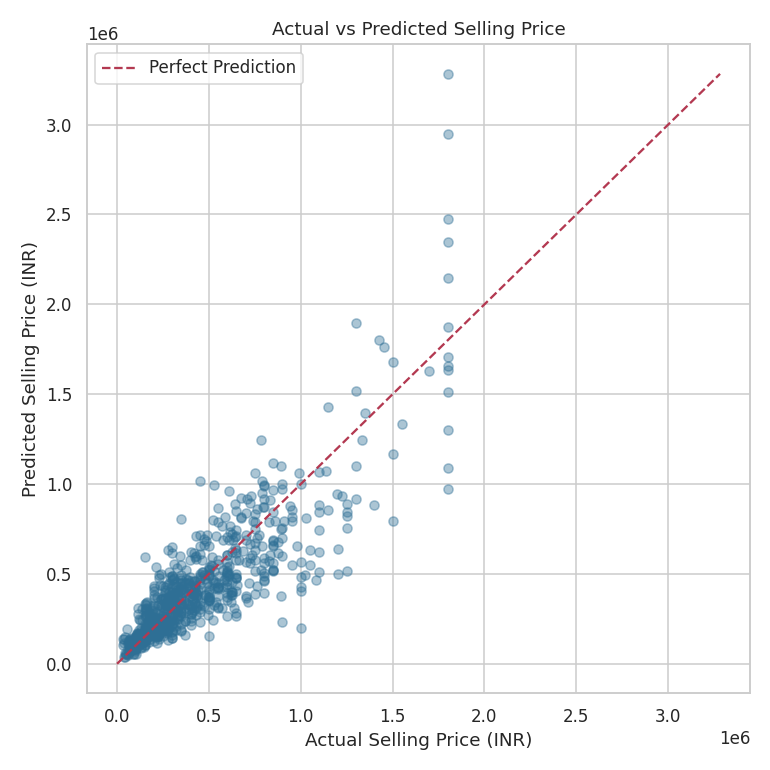

In [ ]:
actual_test_arr = actual_test.values
actual_pred_arr = actual_pred.values
residuals = actual_test_arr - actual_pred_arr

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual_test_arr, actual_pred_arr, alpha=0.4, color="#2E6F95")
lims = [0, max(actual_test_arr.max(), actual_pred_arr.max())]
ax.plot(lims, lims, color="#B33951", linestyle="--", label="Perfect Prediction")
ax.set_xlabel("Actual Selling Price (INR)")
ax.set_ylabel("Predicted Selling Price (INR)")
ax.set_title("Actual vs Predicted Selling Price")
ax.legend()
plt.tight_layout()
plt.show()


### 10.2 — Residual Plot

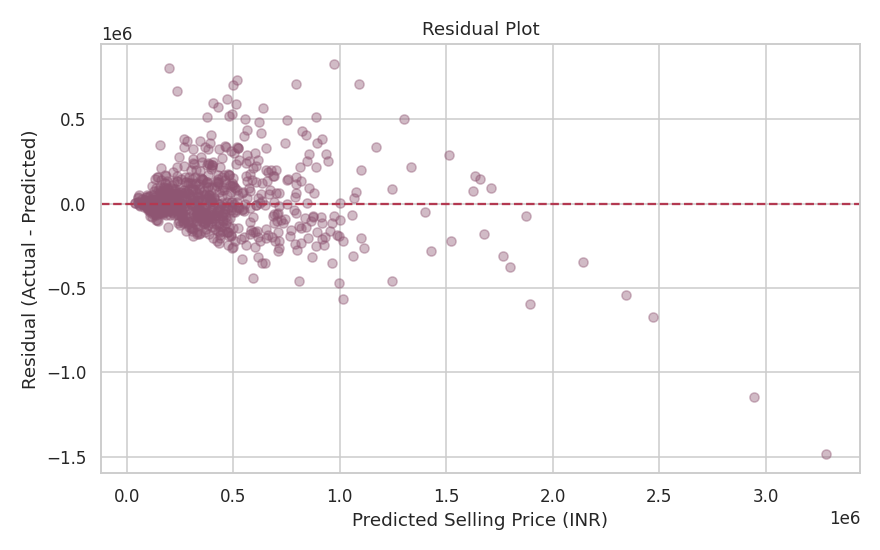

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(actual_pred_arr, residuals, alpha=0.4, color="#8E5572")
ax.axhline(0, color="#B33951", linestyle="--")
ax.set_xlabel("Predicted Selling Price (INR)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residual Plot")
plt.tight_layout()
plt.show()


### 10.3 — Prediction Error Distribution (%)

Median absolute % error: 24.29 %


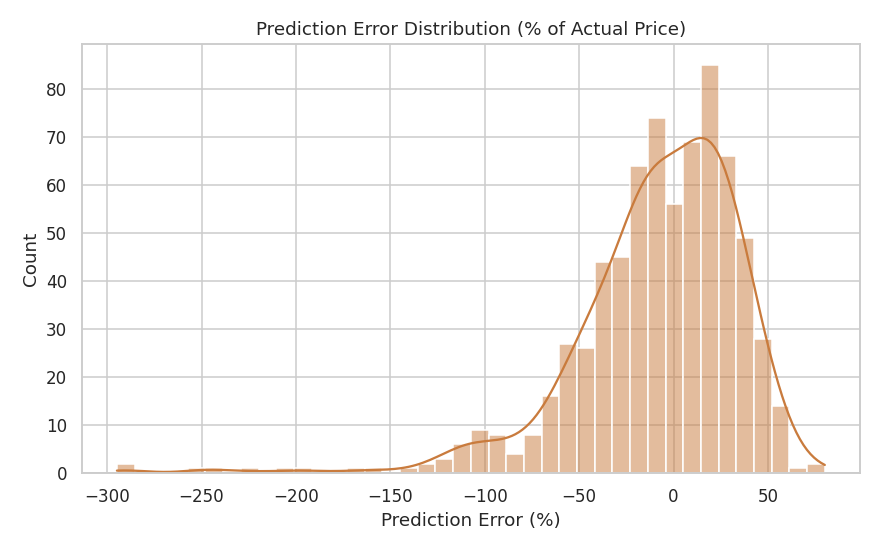

In [ ]:
pct_error = (residuals / np.where(actual_test_arr == 0, np.nan, actual_test_arr)) * 100
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(pd.Series(pct_error).dropna(), bins=40, color="#C97B3D", kde=True, ax=ax)
ax.set_title("Prediction Error Distribution (% of Actual Price)")
ax.set_xlabel("Prediction Error (%)")
plt.tight_layout()
plt.show()

print("Median absolute % error:", round(pd.Series(pct_error).abs().median(), 2), "%")


Mean residual: 15630.46 (close to 0 indicates no systematic bias)


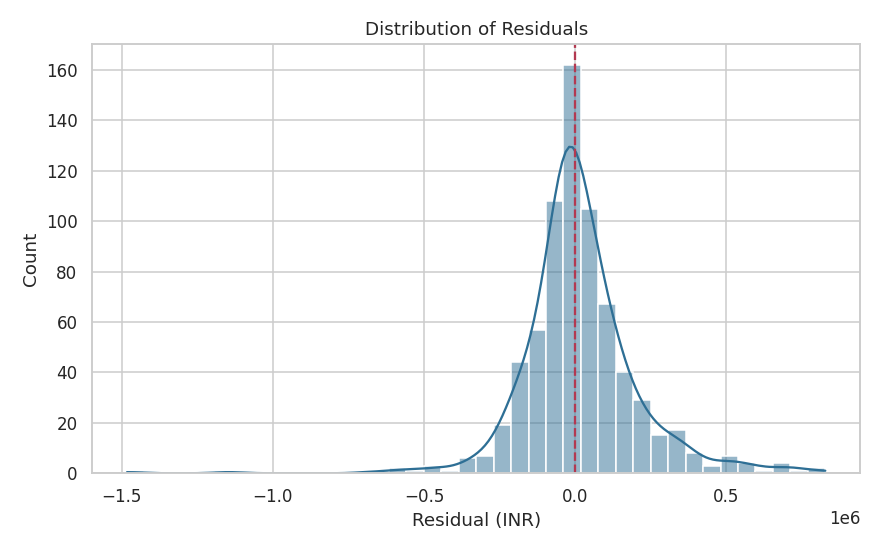

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True, color="#2E6F95", ax=ax)
ax.axvline(0, color="#B33951", linestyle="--")
ax.set_title("Distribution of Residuals")
ax.set_xlabel("Residual (INR)")
plt.tight_layout()
plt.show()

print("Mean residual:", round(residuals.mean(), 2), "(close to 0 indicates no systematic bias)")


Top 15 features by absolute coefficient magnitude:
         feature  coefficient
      brand_Tata    -1.339322
    brand_Datsun    -1.247596
      brand_Fiat    -1.233311
 brand_Chevrolet    -1.197937
   brand_Renault    -1.023541
    brand_Maruti    -0.973041
      brand_Ford    -0.890894
    brand_Nissan    -0.887742
   brand_Hyundai    -0.848469
brand_Volkswagen    -0.813285
     brand_Skoda    -0.731895
  brand_Mahindra    -0.696074
     brand_Honda    -0.651279
     fuel_Diesel     0.508998


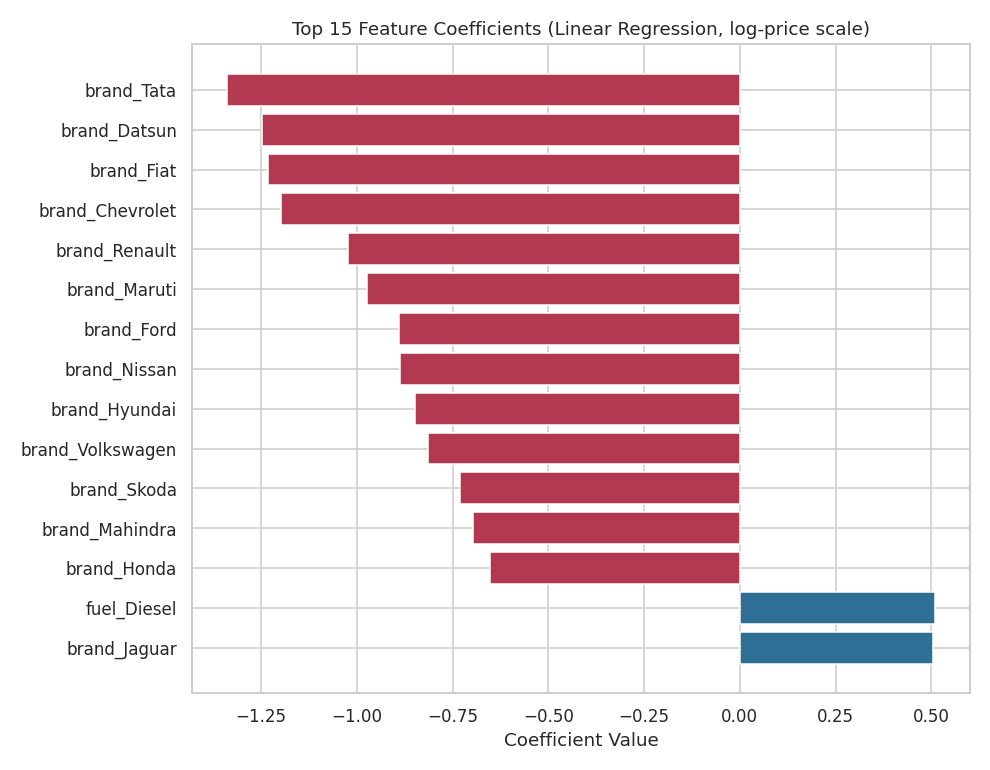

In [ ]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

top_coef = coef_df.head(15)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#2E6F95" if c > 0 else "#B33951" for c in top_coef["coefficient"]]
ax.barh(top_coef["feature"][::-1], top_coef["coefficient"][::-1], color=colors[::-1])
ax.set_title("Top 15 Feature Coefficients (Linear Regression, log-price scale)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print("Top 15 features by absolute coefficient magnitude:")
print(top_coef.to_string(index=False))


In [ ]:
# Save the trained model
joblib.dump(model, "model/linear_regression_model.joblib")

# Save the exact list of engineered feature-column names -- one-hot encoded
# columns must match exactly (same names, same order) when reused on new data
feature_columns = list(X_train.columns)
joblib.dump(feature_columns, "model/feature_columns.joblib")

print("Saved artifacts in the 'model/' directory:")
print(" - linear_regression_model.joblib  (trained model)")
print(" - scaler.joblib                   (fitted StandardScaler for km_driven, car_age)")
print(" - feature_columns.joblib          (exact column order expected by the model)")

# Demonstration: reload the model and artifacts exactly as a new session would
loaded_model = joblib.load("model/linear_regression_model.joblib")
loaded_scaler = joblib.load("model/scaler.joblib")
loaded_columns = joblib.load("model/feature_columns.joblib")

print()
print("Reload check -> model type:", type(loaded_model).__name__)
print("Reload check -> number of expected features:", len(loaded_columns))


Saved artifacts in the 'model/' directory:
 - linear_regression_model.joblib  (trained model)
 - scaler.joblib                   (fitted StandardScaler for km_driven, car_age)
 - feature_columns.joblib          (exact column order expected by the model)

Reload check -> model type: LinearRegression
Reload check -> number of expected features: 33
